In [2]:
from ultralytics import YOLO  #从ultralytics中导入YOLO这个类

yolo = YOLO("./yolov8n.pt", task="detect")  #实例化YOLO这个对象, 这里面我们需要指定两个参数, 第一个是指定我们需要加载哪个模型, 第二个参数task, 如果要让它做检测任务的话, 就可以为"detect". 这个task也不是必须写的, 只要有前面的"./yolov8n.pt", 它就会自动去推理要去做哪个任务

result = yolo(source=r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\bus.jpg", save=True)  #接下来, 调用这个yolo, 指定这个source就可以进行检测了, 如果说我们需要往下保存模型的话, 就要把 save 参数指定上, save=True, 这样它就会将结果存在 runs 下面


image 1/1 D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 113.6ms
Speed: 4.1ms preprocess, 113.6ms inference, 16.9ms postprocess per image at shape (1, 3, 640, 480)
Results saved to D:\Tech\Code\Program\runs\detect\predict8


In [3]:
result[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant',

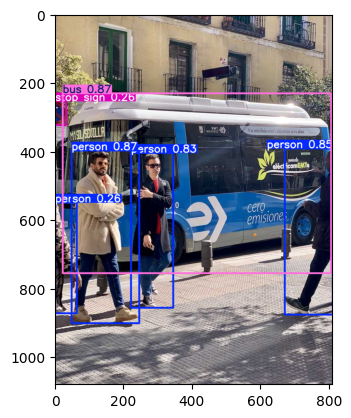

In [4]:
#检测结果可视化
# %matplotlib inline 是jupyter的魔法命令(magic command), 用于将 Matplotlib 绘制的图形直接嵌入到 Notebook 的单元格输出中, 而不是弹出独立的窗口.
# 魔法命令 后不能直接跟注释, 否则将导致解释器将 # 及其后的内容当成命令的参数, 导致报错
import matplotlib.pyplot as plt  
%matplotlib inline 
plt.imshow(result[0].plot()[:,:,::-1])   #对第三个维度(通道)进行翻转通道顺序的转换, 即 BGR -> RGB

In [8]:
# result[0].boxes   #完整的result的第一张图片 result[0] 的 boxes 信息
# result[0].boxes.xywh  # 第一张图片 result[0] 的 boxes 信息中的 xywh 信息, 得到的是 tensor 数据类型
result[0].boxes.xywh.cpu().numpy()  # 调用下cpu(), 再调用下numpy(), 将 tensor数据类型 转为 numpy 数据类型

array([[     413.93,      494.06,      782.11,      525.56],
       [     146.95,      650.64,       196.8,      504.16],
       [     739.59,      634.61,      140.25,      484.83],
       [     283.24,      631.67,      123.46,      451.74],
       [     31.516,      711.98,      63.031,      322.91],
       [     16.309,      289.67,      32.501,      70.417]], dtype=float32)

In [14]:
#关于jupyter的使用过程中, 要重新加载模型, 否则预测过程中的参数将不会更新, 除非手动再次给出.
#比方说我们还要做一个检测, 加了一个参数 save_txt=True
# result = yolo(source=r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\bus.jpg", save_txt=True)  #这个时候很正常, 它将结果写入到了predict8中

#比方说我们想换一张图片进行检测, 如 assets 里另一张图片
#这个时候我们不想让它保存, 将 save_txt=True 参数去掉, 发现并没有什么用, 它还是将最终结果存下去了, 这时就要通过重新加载模型来避免这种问题了, 即重新执行 YOLO("model.pt"), 即上述的 yolo = YOLO("./yolov8n.pt", task="detect") 
# result = yolo(source=r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\zidane.jpg")

#如果说并不想重新加载模型, 可以将 save_txt 参数拿回来, 然后强制的, 再把它设成 False, 这样的话, 它就不会被刚才我们所设置的参数所影响了
result = yolo(source=r"D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\zidane.jpg", save_txt=False)


image 1/1 D:\Tech\Code\Program\yolov8\ultralytics-main\ultralytics\assets\zidane.jpg: 384x640 2 persons, 1 tie, 8.6ms
Speed: 1.5ms preprocess, 8.6ms inference, 1.8ms postprocess per image at shape (1, 3, 384, 640)
